In [161]:
from typing import List, Tuple

import numpy as np
from qiskit.circuit.library import CXGate, SwapGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from scipy.optimize import linprog

from gulps.linear_program import MinimalOrderedISAConstraints
from gulps.utils.invariants import LEN_GATE_INVARIANTS, GateInvariants
from gulps.utils.qlr import len_qlr, qlr_inequalities
from gulps.utils.visualize import render_path

In [162]:
isa_sequence = [
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    # GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
]
constraints = MinimalOrderedISAConstraints(isa_sequence)

In [163]:
u = random_unitary(4)
# u = SwapGate().to_matrix()
gi = GateInvariants.from_unitary(u)

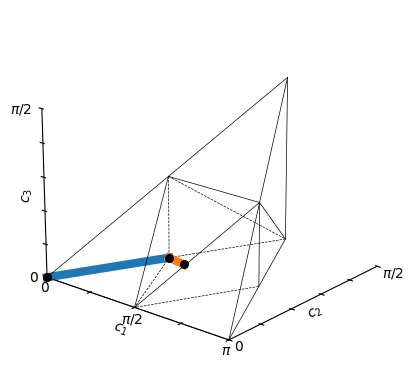

In [ ]:
constraints.set_target(gi)

sentence, intermediates = constraints.solve(log_output=False)
if sentence is None:
    constraints.set_target(gi, rho_reflect=True)
    sentence, intermediates = constraints.solve(log_output=False)
if sentence is None:
    raise ValueError("No solution found for the given gate invariants.")
else:
    render_path(intermediates)